In [ ]:
import requests
from bs4 import BeautifulSoup
print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
import requests
url="https://books.toscrape.com/"
response = requests.get(url)
print(response.status_code)

200


In [ ]:
response = requests.get(url)

In [ ]:
response.text

'<!DOCTYPE html>\n<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->\n<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->\n<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->\n<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->\n    <head>\n        <title>\n    All products | Books to Scrape - Sandbox\n</title>\n\n        <meta http-equiv="content-type" content="text/html; charset=UTF-8" />\n        <meta name="created" content="24th Jun 2016 09:29" />\n        <meta name="description" content="" />\n        <meta name="viewport" content="width=device-width" />\n        <meta name="robots" content="NOARCHIVE,NOCACHE" />\n\n        <!-- Le HTML5 shim, for IE6-8 support of HTML elements -->\n        <!--[if lt IE 9]>\n        <script src="//html5shim.googlecode.com/svn/trunk/html5.js"></script>\n        <![endif]-->\n\n        \n            <link rel="shortcut icon" href

In [ ]:
print(response.text[:500])

<!DOCTYPE html>
<!--[if lt IE 7]>      <html lang="en-us" class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html lang="en-us" class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html lang="en-us" class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html lang="en-us" class="no-js"> <!--<![endif]-->
    <head>
        <title>
    All products | Books to Scrape - Sandbox
</title>

        <meta http-equiv="content-type" content="text/html; charset=UTF-8" /


In [ ]:
soup = BeautifulSoup(response.text, "html.parser")
print(type(soup))

<class 'bs4.BeautifulSoup'>


In [ ]:
print(soup.title.text)
products = soup.find_all("article",class_="product_pod")
print(len(products))
first_product = products[0]
print(first_product.h3.a["title"])

price = first_product.find("p",class_="price_color").text
print(price)


    All products | Books to Scrape - Sandbox

20
A Light in the Attic
Â£51.77


In [ ]:
for product in products:
  name = product.h3.a["title"]
  price = product.find("p", class_="price_color").text
  print("Book:",name)
  print("Price:",price)
  print("-"*40)

Book: A Light in the Attic
Price: Â£51.77
----------------------------------------
Book: Tipping the Velvet
Price: Â£53.74
----------------------------------------
Book: Soumission
Price: Â£50.10
----------------------------------------
Book: Sharp Objects
Price: Â£47.82
----------------------------------------
Book: Sapiens: A Brief History of Humankind
Price: Â£54.23
----------------------------------------
Book: The Requiem Red
Price: Â£22.65
----------------------------------------
Book: The Dirty Little Secrets of Getting Your Dream Job
Price: Â£33.34
----------------------------------------
Book: The Coming Woman: A Novel Based on the Life of the Infamous Feminist, Victoria Woodhull
Price: Â£17.93
----------------------------------------
Book: The Boys in the Boat: Nine Americans and Their Epic Quest for Gold at the 1936 Berlin Olympics
Price: Â£22.60
----------------------------------------
Book: The Black Maria
Price: Â£52.15
----------------------------------------
Book: Starv

In [ ]:
!pip install google-colab-selenium

In [ ]:
import google_colab_selenium as gs
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd

# Initialize the driver (this handles headless, no-sandbox, and dev-shm-usage automatically)
driver = gs.Chrome()

url = "https://books.toscrape.com/"
books_data = []

try:
    driver.get(url)

    while True:
        # Wait for the book cards to load
        WebDriverWait(driver, 10).until(
            EC.presence_of_element_located((By.CLASS_NAME, "product_pod"))
        )

        # Find all books on the current page
        books = driver.find_elements(By.CLASS_NAME, "product_pod")

        for book in books:
            title = book.find_element(By.TAG_NAME, "h3").find_element(By.TAG_NAME, "a").get_attribute("title")
            price = book.find_element(By.CLASS_NAME, "price_color").text
            books_data.append({"Title": title, "Price": price})

        # Check for 'Next' button to navigate
        try:
            next_button = driver.find_element(By.CSS_SELECTOR, "li.next > a")
            next_button.click()
        except:
            print("Scraping complete. No more pages.")
            break

    # Convert to a Pandas DataFrame for easy viewing in Colab
    df = pd.DataFrame(books_data)
    display(df.head(10))

finally:
    driver.quit()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Scraping complete. No more pages.


,Title,Price
0,A Light in the Attic,£51.77
1,Tipping the Velvet,£53.74
2,Soumission,£50.10
3,Sharp Objects,£47.82
4,Sapiens: A Brief History of Humankind,£54.23
5,The Requiem Red,£22.65
6,The Dirty Little Secrets of Getting Your Dream...,£33.34
7,The Coming Woman: A Novel Based on the Life of...,£17.93
8,The Boys in the Boat: Nine Americans and Their...,£22.60
9,The Black Maria,£52.15


In [ ]:
import requests
from lxml import html
import pandas as pd

base_url = "https://books.toscrape.com/"
current_page_url = "https://books.toscrape.com/index.html"
books_data = []

while current_page_url:
    # 1. Fetch the page content
    response = requests.get(current_page_url)

    # 2. Convert the HTML content into an lxml tree
    tree = html.fromstring(response.content)

    # 3. Find all book containers using XPath
    # In lxml, //article[@class='product_pod'] finds the book blocks
    books = tree.xpath("//article[@class='product_pod']")

    for book in books:
        # Extract title: h3 > a (title attribute)
        title = book.xpath(".//h3/a/@title")[0]

        # Extract price: p[@class='price_color']
        price = book.xpath(".//p[@class='price_color']/text()")[0]

        books_data.append({"Title": title, "Price": price})

    # 4. Handle Pagination
    # Look for the 'next' button link
    next_rel_url = tree.xpath("//li[@class='next']/a/@href")

    if next_rel_url:
        # Since the 'next' URL is relative (e.g., 'catalogue/page-2.html'),
        # we need to handle the URL formatting
        if "catalogue/" in next_rel_url[0]:
            current_page_url = base_url + next_rel_url[0]
        else:
            current_page_url = base_url + "catalogue/" + next_rel_url[0]
    else:
        current_page_url = None

# Results
df = pd.DataFrame(books_data)
print(f"Total books scraped: {len(df)}")
display(df.head(10))

Total books scraped: 1000


,Title,Price
0,A Light in the Attic,£51.77
1,Tipping the Velvet,£53.74
2,Soumission,£50.10
3,Sharp Objects,£47.82
4,Sapiens: A Brief History of Humankind,£54.23
5,The Requiem Red,£22.65
6,The Dirty Little Secrets of Getting Your Dream...,£33.34
7,The Coming Woman: A Novel Based on the Life of...,£17.93
8,The Boys in the Boat: Nine Americans and Their...,£22.60
9,The Black Maria,£52.15


In [ ]:
#EXP = 7
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request

def download_image(url, name):
    urllib.request.urlretrieve(url, name)
    return cv2.imread(name)

img_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg"
img = download_image(img_url, "butterfly.jpg")
print(f"Image  loaded successfully, Original shape: {img.shape}")

Image  loaded successfully, Original shape: (356, 493, 3)


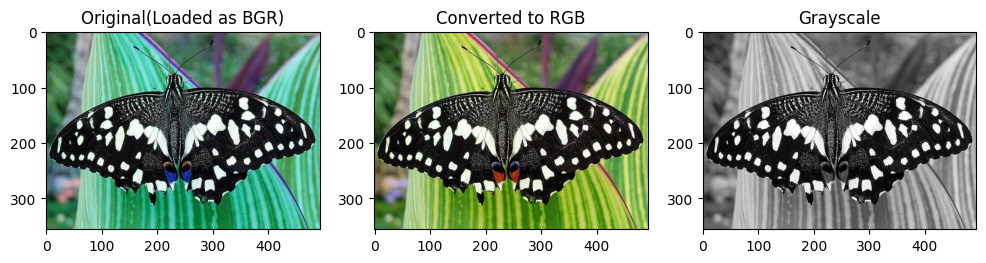

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(12,6))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original(Loaded as BGR)")
plt.subplot(1,3,2); plt.imshow(img_rgb); plt.title("Converted to RGB")
plt.subplot(1,3,3); plt.imshow(img_gray, cmap="gray"); plt.title("Grayscale")
plt.show()

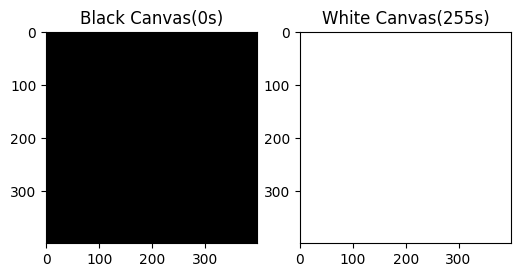

In [ ]:
black_canvas = np.zeros((400,400,3),dtype="uint8")
white_canvas = np.ones((400,400,3), dtype = "uint8") *255
plt.figure(figsize = (6,4))
plt.subplot(1,2,1); plt.imshow(black_canvas); plt.title("Black Canvas(0s)")
plt.subplot(1,2,2); plt.imshow(white_canvas); plt.title("White Canvas(255s)")
plt.show()

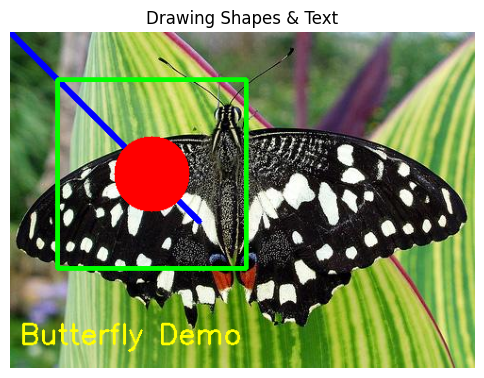

In [ ]:
drawing_demo = img_rgb.copy()
cv2.line(drawing_demo,(0,0),(200,200),(0,0,255),5)
cv2.rectangle(drawing_demo, (50,50),(250,250),(0,255,0),3)
cv2.circle(drawing_demo,(150,150),40,(255,0,0),-1)
cv2.putText(drawing_demo, "Butterfly Demo",(10,330),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0),2)
plt.figure(figsize=(6,6))
plt.imshow(drawing_demo)
plt.title("Drawing Shapes & Text")
plt.axis('off')
plt.show()

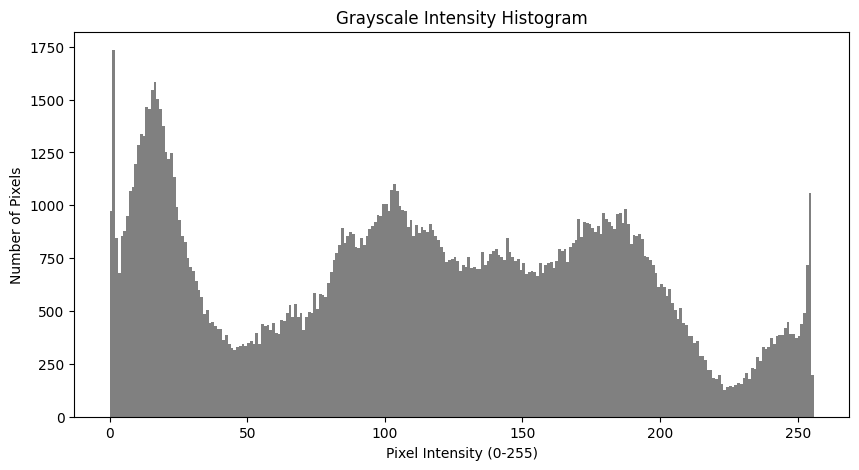

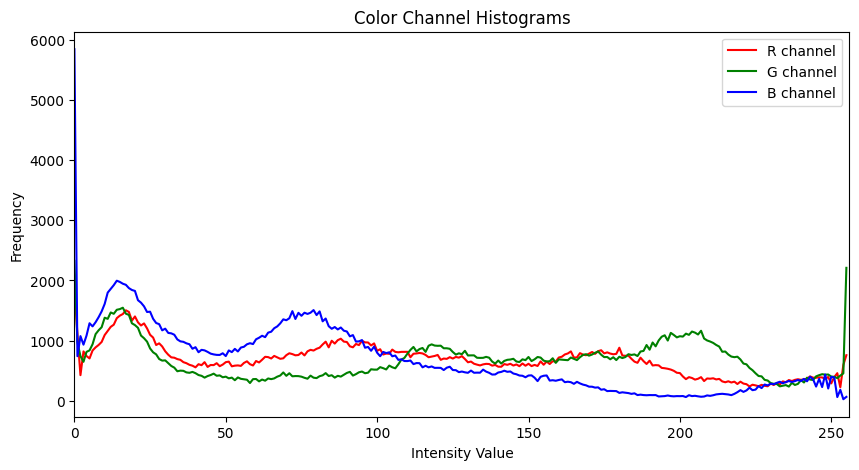

In [ ]:
# 1. Grayscale Histogram (Overall Intensity)
plt.figure(figsize=(10, 5))
plt.title("Grayscale Intensity Histogram")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Number of Pixels")

# Use plt.hist to calculate and plot in one go
# .ravel() flattens the 2D image into a 1D array
plt.hist(img_gray.ravel(), bins=256, range=[0, 256], color='gray')
plt.show()

# 2. Color Channel Histograms
plt.figure(figsize=(10, 5))
plt.title("Color Channel Histograms")
plt.xlabel("Intensity Value")
plt.ylabel("Frequency")

colors = ('r', 'g', 'b')
# OpenCV loads as BGR, but we previously converted 'img_rgb' to RGB
for i, col in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=col, label=f'{col.upper()} channel')
    plt.xlim([0, 256])

plt.legend()
plt.show()

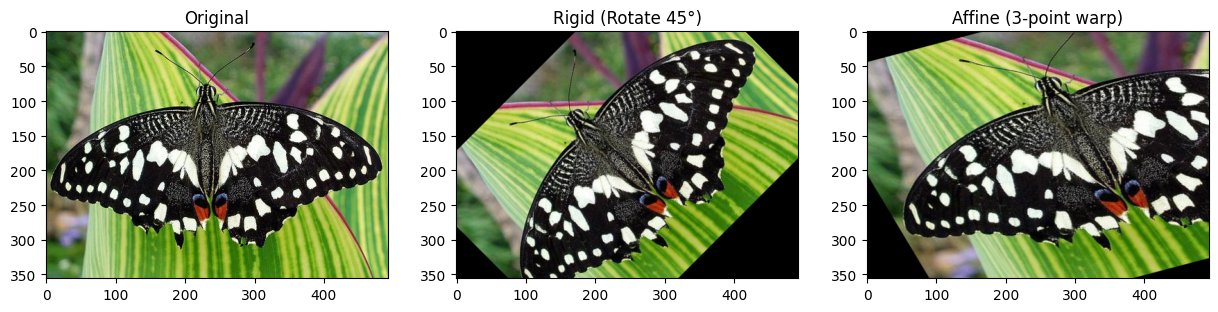

In [ ]:
rows, cols, ch = img_rgb.shape

# --- 1. RIGID TRANSFORMATION (Rotation + Translation) ---
# Create a rotation matrix: Center point, Angle (45 deg), Scale (1.0)
M_rigid = cv2.getRotationMatrix2D((cols/2, rows/2), 45, 1)
# Apply the transformation
rigid_output = cv2.warpAffine(img_rgb, M_rigid, (cols, rows))

# --- 2. AFFINE TRANSFORMATION (Using 3-point mapping) ---
# We define 3 points in the original image and where we want them to move
pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
pts2 = np.float32([[10, 100], [200, 50], [100, 250]])

M_affine = cv2.getAffineTransform(pts1, pts2)
affine_output = cv2.warpAffine(img_rgb, M_affine, (cols, rows))

# --- Visualization ---
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(img_rgb); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(rigid_output); plt.title("Rigid (Rotate 45°)")
plt.subplot(1, 3, 3); plt.imshow(affine_output); plt.title("Affine (3-point warp)")
plt.show()

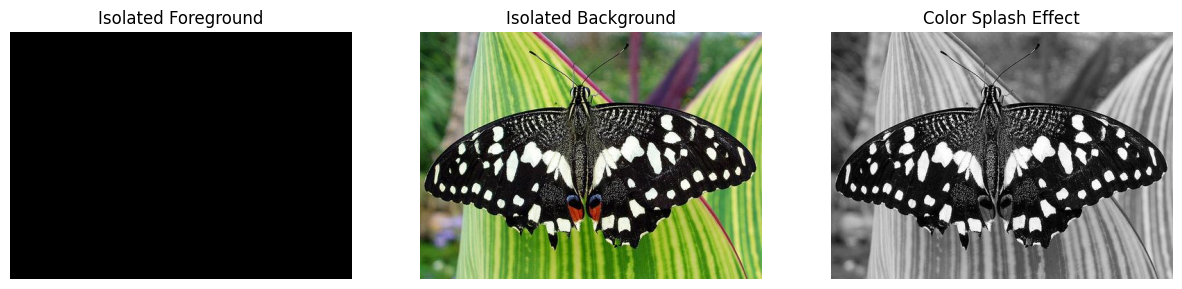

In [ ]:
# Create the mask (MOG2)
backSub = cv2.createBackgroundSubtractorMOG2(varThreshold=50, detectShadows=True)
fg_mask = backSub.apply(img_rgb)

# Remove shadows (gray pixels) from the mask to keep only the 'pure' foreground
_, clean_mask = cv2.threshold(fg_mask, 250, 255, cv2.THRESH_BINARY)

# Apply mask to original image to get color foreground
foreground_only = cv2.bitwise_and(img_rgb, img_rgb, mask=clean_mask)

# Create a background-only view (invert the mask)
background_mask = cv2.bitwise_not(clean_mask)
background_only = cv2.bitwise_and(img_rgb, img_rgb, mask=background_mask)

# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(foreground_only)
plt.title("Isolated Foreground")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(background_only)
plt.title("Isolated Background")
plt.axis('off')

# Combined: Color foreground on a Grayscale background
img_gray_3ch = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB) # Convert gray to 3 channels
bg_gray_part = cv2.bitwise_and(img_gray_3ch, img_gray_3ch, mask=background_mask)
combined_effect = cv2.add(foreground_only, bg_gray_part)

plt.subplot(1, 3, 3)
plt.imshow(combined_effect)
plt.title("Color Splash Effect")
plt.axis('off')

plt.show()

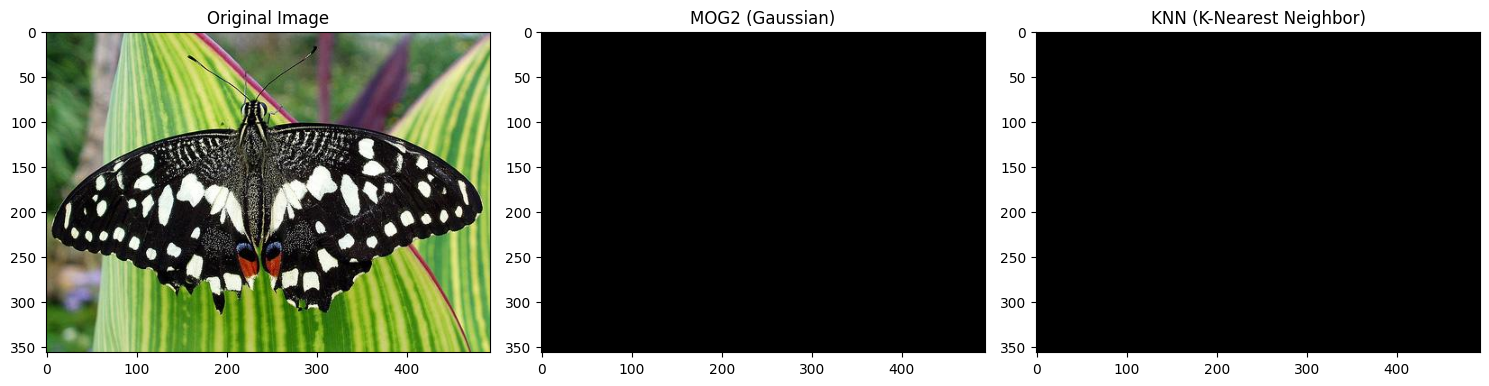

In [ ]:
# Initialize different subtractors
subtractors = {
    "MOG2": cv2.createBackgroundSubtractorMOG2(detectShadows=True),
    "KNN": cv2.createBackgroundSubtractorKNN(detectShadows=True),
}

# In Colab, we simulate the 'adaptive' learning by feeding the image multiple times
results = {}

for name, algo in subtractors.items():
    # Pass the image through the algorithm 10 times to 'train' the model
    for _ in range(10):
        mask = algo.apply(img_rgb)
    results[name] = mask

# Plotting the comparison
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("Original Image")

plt.subplot(1, 3, 2)
plt.imshow(results["MOG2"], cmap='gray')
plt.title("MOG2 (Gaussian)")

plt.subplot(1, 3, 3)
plt.imshow(results["KNN"], cmap='gray')
plt.title("KNN (K-Nearest Neighbor)")

plt.tight_layout()
plt.show()

In [ ]:
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow
print("Please upload a test image containing a face:")
uploaded = files.upload()
filename = next(iter(uploaded))
print(f"Successfully loaded: {filename}")

Please upload a test image containing a face:


Saving kiara.jpg to kiara.jpg
Successfully loaded: kiara.jpg


In [ ]:
image = cv2.imread(filename)
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_smile.xml')

Image prepped and models loaded successfully!


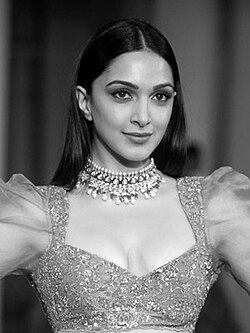

In [ ]:
print("Image prepped and models loaded successfully!")
cv2_imshow(gray_image)

Detection complete! Found 1 face(s).


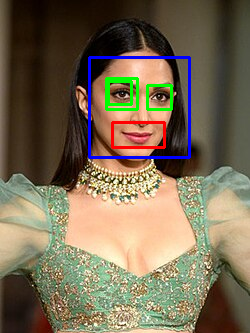

In [ ]:
faces = face_cascade.detectMultiScale(gray_image,scaleFactor=1.1,minNeighbors=5,minSize=(30,30))
print(f"Detection complete! Found {len(faces)} face(s).")
for(x,y,w,h) in faces:
  cv2.rectangle(image, (x,y),(x+w,y+h),(255,0,0),2)
  roi_gray = gray_image[y:y+h, x:x+w]
  roi_color = image[y:y+h, x:x+w]
  half_height = int(h/2)
  top_half_gray = roi_gray[0:int(h*0.65), 0:w]
  top_half_color = roi_color[0:int(h*0.65), 0:w]
  bottom_half_gray = roi_gray[half_height:h, 0:w]
  bottom_half_color = roi_color[half_height:h, 0:w]
  top_gray = cv2.equalizeHist(top_gray)
  eyes = eye_cascade.detectMultiScale(top_half_gray, scaleFactor=1.1, minNeighbors=3, minSize=(15,15))
  for (ex, ey, ew, eh) in eyes:
    cv2.rectangle(top_half_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0),2)

  smiles = smile_cascade.detectMultiScale(bottom_half_gray, scaleFactor=1.3, minNeighbors=10)
  for (sx, sy, sw, sh) in smiles:
    cv2.rectangle(bottom_half_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2)

cv2_imshow(image)

Detection complete! Found 1 face(s).


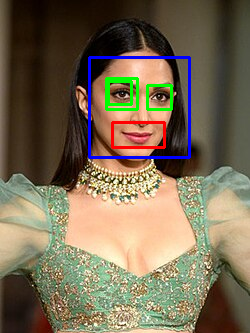

In [ ]:
faces = face_cascade.detectMultiScale(gray_image, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))
print(f"Detection complete! Found {len(faces)} face(s).")

for (x,y,w,h) in faces:
    cv2.rectangle(image, (x,y),(x+w,y+h),(255,0,0),2)

    roi_gray = gray_image[y:y+h, x:x+w]
    roi_color = image[y:y+h, x:x+w]

    half_height = int(h/2)

    # TOP (eyes)
    top_half_gray = roi_gray[0:int(h*0.65), 0:w]
    top_half_color = roi_color[0:int(h*0.65), 0:w]

    # BOTTOM (smile)
    bottom_half_gray = roi_gray[half_height:h, 0:w]
    bottom_half_color = roi_color[half_height:h, 0:w]

    # ---- EYE DETECTION ----
   # ---- EYE DETECTION ----
    eyes = eye_cascade.detectMultiScale(top_half_gray, scaleFactor=1.1, minNeighbors=6, minSize=(20,20))

# Step 1: sort left → right
    eyes = sorted(eyes, key=lambda e: e[0])

    final_eyes = []

    for (ex, ey, ew, eh) in eyes:
      if len(final_eyes) == 0:
          final_eyes.append((ex, ey, ew, eh))
      else:
        # keep second eye only if it's far enough from first
          if abs(ex - final_eyes[0][0]) > w * 0.3:
              final_eyes.append((ex, ey, ew, eh))
              break

# Draw only filtered eyes
    for (ex, ey, ew, eh) in final_eyes:
      cv2.rectangle(top_half_color, (ex, ey), (ex + ew, ey + eh), (0, 255, 0), 2)

    # ---- SMILE DETECTION ----
    smiles = smile_cascade.detectMultiScale(
        bottom_half_gray,
        scaleFactor=1.3,
        minNeighbors=10,
        minSize=(25,25)
    )

    for (sx, sy, sw, sh) in smiles:
        cv2.rectangle(bottom_half_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2)

cv2_imshow(image)